First 5 Rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Dataset Shape: (541909, 8)

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           

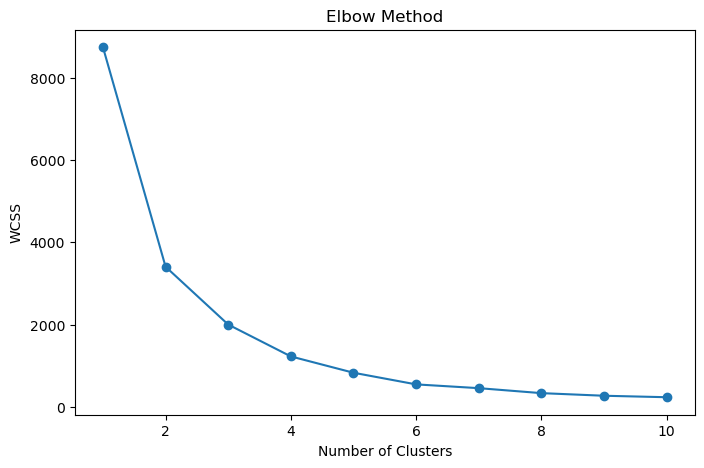

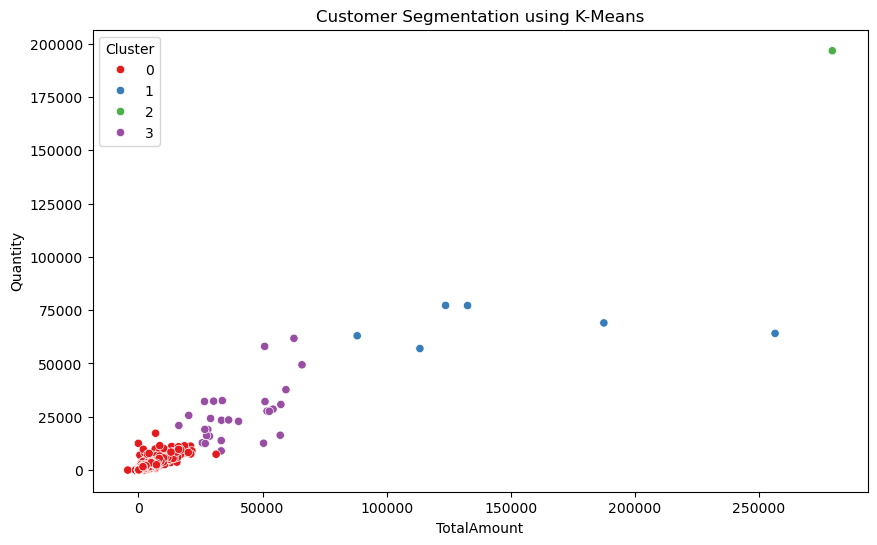


Cluster Counts:
Cluster
0    4337
3      28
1       6
2       1
Name: count, dtype: int64

Sample Segmented Customers:
   CustomerID  TotalAmount  Quantity  Cluster
0     12346.0         0.00         0        0
1     12347.0      4310.00      2458        0
2     12348.0      1797.24      2341        0
3     12349.0      1757.55       631        0
4     12350.0       334.40       197        0
5     12352.0      1545.41       470        0
6     12353.0        89.00        20        0
7     12354.0      1079.40       530        0
8     12355.0       459.40       240        0
9     12356.0      2811.43      1591        0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset
df = pd.read_excel("Online Retail.xlsx")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing Customer IDs
df = df.dropna(subset=['CustomerID'])

# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Customer-wise Aggregation
customer_data = df.groupby('CustomerID').agg({
    'TotalAmount':'sum',
    'Quantity':'sum'
}).reset_index()

print("\nCustomer Data:")
print(customer_data.head())

# Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    customer_data[['TotalAmount','Quantity']]
)

# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# KMeans Model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Cluster Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='TotalAmount',
    y='Quantity',
    hue='Cluster',
    data=customer_data,
    palette='Set1'
)

plt.title("Customer Segmentation using K-Means")
plt.show()

print("\nCluster Counts:")
print(customer_data['Cluster'].value_counts())

print("\nSample Segmented Customers:")
print(customer_data.head(10))